In [30]:
!pip install dagshub mlflow plotly

In [31]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import mlflow
import mlflow.tensorflow
import dagshub
import plotly.graph_objects as go

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

In [32]:
from kaggle_secrets import UserSecretsClient
secret_label = "dagshub_token"
secret_value = UserSecretsClient().get_secret(secret_label)

In [33]:
os.environ["MLFLOW_TRACKING_USERNAME"] = "Aryanupadhyay23"
os.environ["MLFLOW_TRACKING_PASSWORD"] = secret_value

mlflow.set_tracking_uri(
    "https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow"
)

mlflow.set_experiment("resnet50")

<Experiment: artifact_location='mlflow-artifacts:/4a68a28d2d694062b9ed905bf6103138', creation_time=1772861952385, experiment_id='14', last_update_time=1772861952385, lifecycle_stage='active', name='resnet50', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [34]:
DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR = os.path.join(DATASET_PATH,"test")

OUTPUT_DIR = "/kaggle/working/resnet50_mixup_cutmix"
os.makedirs(OUTPUT_DIR,exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

EMOTIONS = ['Surprise','Fear','Disgust','Happy','Sad','Anger','Neutral']
NUM_CLASSES = len(EMOTIONS)

In [35]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.


In [36]:
def apply_basic_aug(image, label):
    # 1. Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # 2. Random contrast and brightness
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_brightness(image, max_delta=0.1)
    
    # 3. Simulate Translation/Zoom with Random Crop
    # Pad the image slightly, then randomly crop it back down to 224x224
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 20, IMG_SIZE + 20)
    
    # FIX: Dynamically get the batch size to match the 4D tensor shape
    batch_size = tf.shape(image)[0]
    image = tf.image.random_crop(image, size=[batch_size, IMG_SIZE, IMG_SIZE, 3])
    
    return image, label

In [37]:
def sample_beta(alpha=0.2):
    """Samples from a Beta distribution using the Gamma distribution trick."""
    gamma_1 = tf.random.gamma(shape=[], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[], alpha=alpha)
    return gamma_1 / (gamma_1 + gamma_2)

def mixup(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    lam = sample_beta(alpha)
    
    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)
    
    images = lam * images + (1.0 - lam) * images_shuffled
    labels = lam * labels + (1.0 - lam) * labels_shuffled
    return images, labels

def cutmix(images, labels, alpha=1.0):
    batch_size = tf.shape(images)[0]
    image_size = tf.shape(images)[1]
    
    lam = sample_beta(alpha)
    
    # Calculate bounding box dimensions
    cut_rat = tf.math.sqrt(1. - lam)
    cut_w = tf.cast(tf.cast(image_size, tf.float32) * cut_rat, tf.int32)
    cut_h = tf.cast(tf.cast(image_size, tf.float32) * cut_rat, tf.int32)
    
    cx = tf.random.uniform([], minval=0, maxval=image_size, dtype=tf.int32)
    cy = tf.random.uniform([], minval=0, maxval=image_size, dtype=tf.int32)
    
    bbx1 = tf.clip_by_value(cx - cut_w // 2, 0, image_size)
    bby1 = tf.clip_by_value(cy - cut_h // 2, 0, image_size)
    bbx2 = tf.clip_by_value(cx + cut_w // 2, 0, image_size)
    bby2 = tf.clip_by_value(cy + cut_h // 2, 0, image_size)
    
    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)
    
    # Create spatial mask
    xx, yy = tf.meshgrid(tf.range(image_size), tf.range(image_size))
    mask_x = (xx >= bbx1) & (xx < bbx2)
    mask_y = (yy >= bby1) & (yy < bby2)
    mask = tf.cast(mask_x & mask_y, tf.float32)
    mask = tf.expand_dims(mask, -1) 
    
    images = images * (1. - mask) + images_shuffled * mask
    
    # Adjust lambda to exact pixel area
    actual_lam = 1. - tf.cast((bbx2 - bbx1) * (bby2 - bby1), tf.float32) / tf.cast(image_size * image_size, tf.float32)
    labels = actual_lam * labels + (1. - actual_lam) * labels_shuffled
    
    return images, labels

def apply_advanced_aug(images, labels):
    """Randomly applies MixUp (40%), CutMix (40%), or nothing (20%)."""
    rand_val = tf.random.uniform([])
    
    # tf.cond expects callables returning tensors
    def apply_mixup(): return mixup(images, labels)
    def apply_cutmix(): return cutmix(images, labels)
    def apply_nothing(): return images, labels

    return tf.case(
        [
            (rand_val < 0.4, apply_mixup),
            ((rand_val >= 0.4) & (rand_val < 0.8), apply_cutmix),
        ],
        default=apply_nothing
    )

In [38]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(apply_basic_aug,num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(apply_advanced_aug,num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [39]:
run = mlflow.start_run(run_name="resnet50_mixup_cutmix")

mlflow.log_param("model","ResNet50")
mlflow.log_param("augmentation","mixup_cutmix")
mlflow.log_param("img_size",IMG_SIZE)
mlflow.log_param("batch_size",BATCH_SIZE)
mlflow.log_param("epochs",EPOCHS)

100

In [40]:
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable=True

inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = keras.applications.resnet.preprocess_input(inputs)

x = base_model(x)

attention = layers.Conv2D(1,kernel_size=1,activation="sigmoid")(x)
attention = layers.Multiply()([x,attention])

x = layers.GlobalAveragePooling2D()(attention)
x = layers.BatchNormalization()(x)

x = layers.Dense(512,activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128,activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 1)   │      2,049 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│ (Multiply)          │ 2048)             │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,049,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,664 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7)         │        903 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,713,608 (94.27 MB)

 Trainable params: 24,656,392 (94.06 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [41]:
with open("model_summary.txt","w") as f:
    model.summary(print_fn=lambda x: f.write(x+"\n"))

mlflow.log_artifact("model_summary.txt")

In [42]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

In [43]:
callbacks=[

keras.callbacks.ModelCheckpoint(

    os.path.join(OUTPUT_DIR,"best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1

),

keras.callbacks.EarlyStopping(

    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True

),

keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1

),

keras.callbacks.CSVLogger(

    os.path.join(OUTPUT_DIR,"training_log.csv")

)

]

In [44]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.3084 - loss: 2.1572
Epoch 1: val_accuracy improved from -inf to 0.58638, saving model to /kaggle/working/resnet50_mixup_cutmix/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 145s 248ms/step - accuracy: 0.3085 - loss: 2.1566 - val_accuracy: 0.5864 - val_loss: 1.3857 - learning_rate: 1.0000e-04
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5161 - loss: 1.5501
Epoch 2: val_accuracy improved from 0.58638 to 0.68123, saving model to /kaggle/working/resnet50_mixup_cutmix/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 70s 182ms/step - accuracy: 0.5162 - loss: 1.5499 - val_accuracy: 0.6812 - val_loss: 1.1825 - learning_rate: 1.0000e-04
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6021 - loss: 1.4037
Epoch 3: val_accuracy improved from 0.68123 to 0.73957, saving model to /kaggle/working/resnet50_mixup_cutmix/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 70s 182ms/step - accuracy: 0.

In [45]:
for i in range(len(history.history["accuracy"])):

    mlflow.log_metric("train_accuracy",history.history["accuracy"][i],step=i)
    mlflow.log_metric("val_accuracy",history.history["val_accuracy"][i],step=i)

    mlflow.log_metric("train_loss",history.history["loss"][i],step=i)
    mlflow.log_metric("val_loss",history.history["val_loss"][i],step=i)

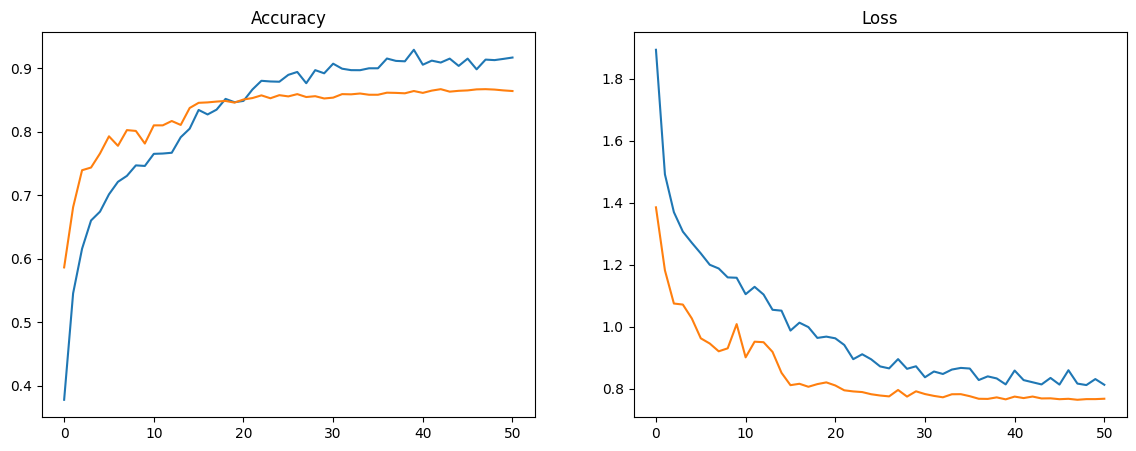

In [46]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")

curve_path=os.path.join(OUTPUT_DIR,"training_curves.png")

plt.savefig(curve_path)

mlflow.log_artifact(curve_path)

plt.show()

In [47]:
best_model = model

y_true=[]
y_pred=[]
y_prob=[]

for x,y in test_ds:

    preds = best_model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

y_true=np.array(y_true)
y_pred=np.array(y_pred)
y_prob=np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━

In [48]:
acc = accuracy_score(y_true,y_pred)

mlflow.log_metric("test_accuracy",acc)

print("Test Accuracy:",acc)

Test Accuracy: 0.8673402868318123


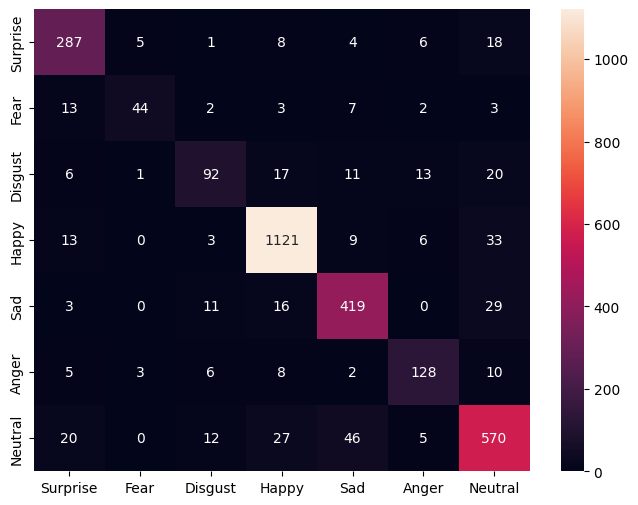

In [49]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

cm_path=os.path.join(OUTPUT_DIR,"confusion_matrix.png")

plt.savefig(cm_path)

mlflow.log_artifact(cm_path)

plt.show()

In [50]:
y_true_bin = label_binarize(y_true,classes=list(range(NUM_CLASSES)))

roc_macro = roc_auc_score(y_true_bin,y_prob,average="macro",multi_class="ovr")
roc_micro = roc_auc_score(y_true_bin,y_prob,average="micro",multi_class="ovr")

mlflow.log_metric("roc_auc_macro",roc_macro)
mlflow.log_metric("roc_auc_micro",roc_micro)

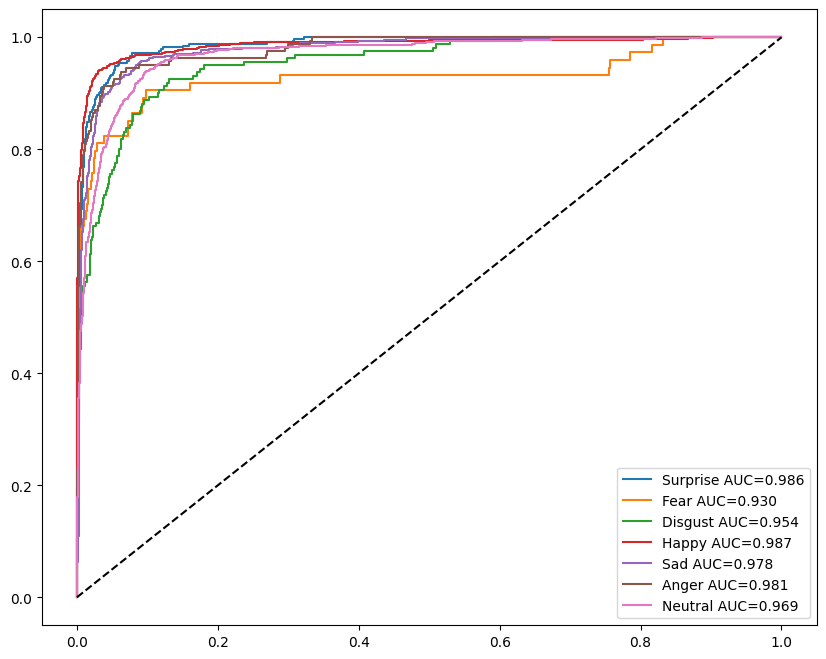

In [51]:
plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    auc_score = roc_auc_score(y_true_bin[:,i],y_prob[:,i])

    mlflow.log_metric(f"roc_auc_{EMOTIONS[i]}",auc_score)

    plt.plot(fpr,tpr,label=f"{EMOTIONS[i]} AUC={auc_score:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.legend()

roc_path=os.path.join(OUTPUT_DIR,"roc_curve.png")

plt.savefig(roc_path)

mlflow.log_artifact(roc_path)

plt.show()

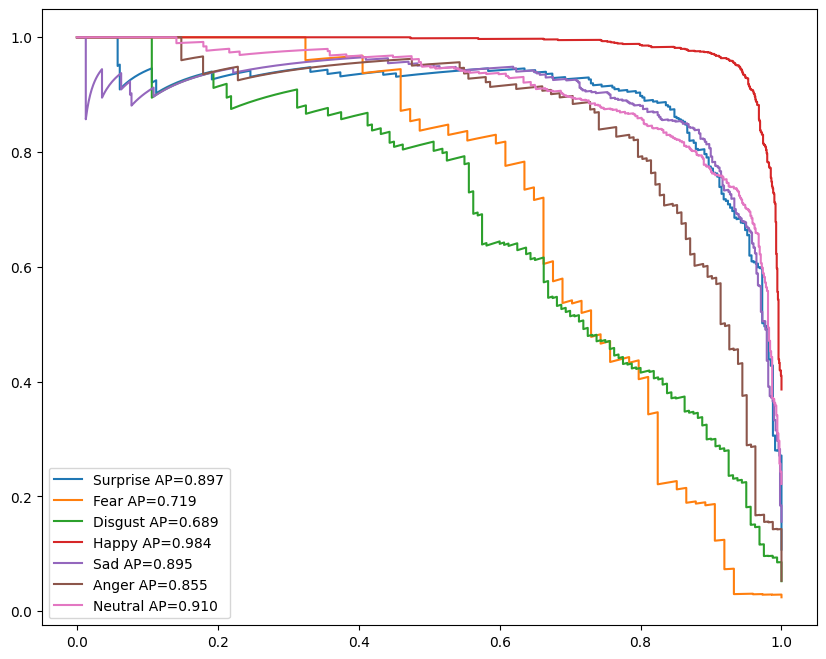

In [52]:
plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    precision,recall,_ = precision_recall_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    ap = average_precision_score(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    mlflow.log_metric(f"ap_{EMOTIONS[i]}",ap)

    plt.plot(recall,precision,label=f"{EMOTIONS[i]} AP={ap:.3f}")

plt.legend()

pr_path=os.path.join(OUTPUT_DIR,"precision_recall.png")

plt.savefig(pr_path)

mlflow.log_artifact(pr_path)

plt.show()

In [53]:
fig = go.Figure()

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    fig.add_trace(
        go.Scatter(x=fpr,y=tpr,mode='lines',name=EMOTIONS[i])
    )

fig.update_layout(
    title="Interactive ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

interactive_path=os.path.join(OUTPUT_DIR,"interactive_roc.html")

fig.write_html(interactive_path)

mlflow.log_artifact(interactive_path)

In [54]:
mlflow.tensorflow.log_model(
    model,
    artifact_path="model"
)

2026/03/07 08:30:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 08:30:46 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [55]:
mlflow.end_run()

🏃 View run resnet50_mixup_cutmix at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/14/runs/7e48f7d2b57046408136c71f4378a413
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/14
